## Import Libraries


In [1]:
import numpy as np
import pandas as pd
import glob
import os
import gc  
import joblib

import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from fastai.tabular.all import df_shrink
from fastcore.parallel import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [232]:
folder_path = 'data/shrinked'
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"Found {len(csv_files)} CSV files. Loading directly into memory...\n")

individual_dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    individual_dfs.append(df)
    
    print(f"  - Loaded: {os.path.basename(file)} | Shape: {df.shape}")

print(f"\n✅ Success! You now have {len(individual_dfs)} DataFrames loaded in your 'individual_dfs' list.")

# Total 11,30,650 Rows

Found 17 CSV files. Loading directly into memory...

  - Loaded: DNS-testing.csv | Shape: (34020, 88)
  - Loaded: LDAP-testing.csv | Shape: (16120, 88)
  - Loaded: LDAP-training.csv | Shape: (51240, 88)
  - Loaded: MSSQL-testing.csv | Shape: (20060, 88)
  - Loaded: MSSQL-training.csv | Shape: (27940, 88)
  - Loaded: NetBIOS-testing.csv | Shape: (17070, 88)
  - Loaded: NetBIOS-training.csv | Shape: (13210, 88)
  - Loaded: NTP-testing.csv | Shape: (143650, 88)
  - Loaded: Portmap-training.csv | Shape: (47340, 88)
  - Loaded: SNMP-testing.csv | Shape: (15070, 88)
  - Loaded: Syn-testing.csv | Shape: (3920, 88)
  - Loaded: Syn-training.csv | Shape: (357900, 88)
  - Loaded: TFTP-testing.csv | Shape: (252470, 88)
  - Loaded: UDP-testing.csv | Shape: (21570, 88)
  - Loaded: UDP-training.csv | Shape: (31340, 88)
  - Loaded: UDPLag-testing.csv | Shape: (37050, 88)
  - Loaded: UDPLag-training.csv | Shape: (40680, 88)

✅ Success! You now have 17 DataFrames loaded in your 'individual_dfs' list.


#### Column name consistency

In [233]:
col_name_consistency = {
'Flow ID': 'Flow ID',
'Source IP': 'Source IP',
'Src IP':  'Source IP',
'Source Port': 'Source Port',
'Src Port': 'Source Port',
'Destination IP': 'Destination IP',
'Dst IP': 'Destination IP',
'Destination Port': 'Destination Port',
'Dst Port': 'Destination Port',
'Protocol': 'Protocol',
'Timestamp': 'Timestamp',
'Flow Duration': 'Flow Duration',
'Total Fwd Packets': 'Total Fwd Packets',
'Tot Fwd Pkts': 'Total Fwd Packets',
'Total Backward Packets': 'Total Backward Packets',
'Tot Bwd Pkts': 'Total Backward Packets',
'Total Length of Fwd Packets': 'Fwd Packets Length Total',
'TotLen Fwd Pkts': 'Fwd Packets Length Total',
'Total Length of Bwd Packets': 'Bwd Packets Length Total',
'TotLen Bwd Pkts': 'Bwd Packets Length Total',
'Fwd Packet Length Max': 'Fwd Packet Length Max',
'Fwd Pkt Len Max': 'Fwd Packet Length Max',
'Fwd Packet Length Min': 'Fwd Packet Length Min',
'Fwd Pkt Len Min': 'Fwd Packet Length Min',
'Fwd Packet Length Mean': 'Fwd Packet Length Mean',
'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
'Fwd Packet Length Std': 'Fwd Packet Length Std',
'Fwd Pkt Len Std': 'Fwd Packet Length Std',
'Bwd Packet Length Max': 'Bwd Packet Length Max',
'Bwd Pkt Len Max': 'Bwd Packet Length Max',
'Bwd Packet Length Min': 'Bwd Packet Length Min',
'Bwd Pkt Len Min': 'Bwd Packet Length Min',
'Bwd Packet Length Mean': 'Bwd Packet Length Mean',
'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
'Bwd Packet Length Std': 'Bwd Packet Length Std',
'Bwd Pkt Len Std': 'Bwd Packet Length Std',
'Flow Bytes/s': 'Flow Bytes/s',
'Flow Byts/s': 'Flow Bytes/s',
'Flow Packets/s': 'Flow Packets/s',
'Flow Pkts/s': 'Flow Packets/s',
'Flow IAT Mean': 'Flow IAT Mean',
'Flow IAT Std': 'Flow IAT Std',
'Flow IAT Max': 'Flow IAT Max',
'Flow IAT Min': 'Flow IAT Min',
'Fwd IAT Total': 'Fwd IAT Total',
'Fwd IAT Tot': 'Fwd IAT Total',
'Fwd IAT Mean': 'Fwd IAT Mean',
'Fwd IAT Std': 'Fwd IAT Std',
'Fwd IAT Max': 'Fwd IAT Max',
'Fwd IAT Min': 'Fwd IAT Min',
'Bwd IAT Total': 'Bwd IAT Total',
'Bwd IAT Tot': 'Bwd IAT Total',
'Bwd IAT Mean': 'Bwd IAT Mean',
'Bwd IAT Std': 'Bwd IAT Std',
'Bwd IAT Max': 'Bwd IAT Max',
'Bwd IAT Min': 'Bwd IAT Min',
'Fwd PSH Flags': 'Fwd PSH Flags',
'Bwd PSH Flags': 'Bwd PSH Flags',
'Fwd URG Flags': 'Fwd URG Flags',
'Bwd URG Flags': 'Bwd URG Flags',
'Fwd Header Length': 'Fwd Header Length',
'Fwd Header Len': 'Fwd Header Length',
'Bwd Header Length': 'Bwd Header Length',
'Bwd Header Len': 'Bwd Header Length',
'Fwd Packets/s': 'Fwd Packets/s',
'Fwd Pkts/s': 'Fwd Packets/s',
'Bwd Packets/s': 'Bwd Packets/s',
'Bwd Pkts/s': 'Bwd Packets/s',
'Min Packet Length': 'Packet Length Min',
'Pkt Len Min': 'Packet Length Min',
'Max Packet Length': 'Packet Length Max',
'Pkt Len Max': 'Packet Length Max',
'Packet Length Mean': 'Packet Length Mean',
'Pkt Len Mean': 'Packet Length Mean',
'Packet Length Std': 'Packet Length Std',
'Pkt Len Std': 'Packet Length Std',
'Packet Length Variance': 'Packet Length Variance',
'Pkt Len Var': 'Packet Length Variance',
'FIN Flag Count': 'FIN Flag Count',
'FIN Flag Cnt': 'FIN Flag Count',
'SYN Flag Count': 'SYN Flag Count',
'SYN Flag Cnt': 'SYN Flag Count',
'RST Flag Count': 'RST Flag Count',
'RST Flag Cnt': 'RST Flag Count',
'PSH Flag Count': 'PSH Flag Count',
'PSH Flag Cnt': 'PSH Flag Count',
'ACK Flag Count': 'ACK Flag Count',
'ACK Flag Cnt': 'ACK Flag Count',
'URG Flag Count': 'URG Flag Count',
'URG Flag Cnt': 'URG Flag Count',
'CWE Flag Count': 'CWE Flag Count',
'CWE Flag Cnt': 'CWE Flag Count',
'ECE Flag Count': 'ECE Flag Count',
'ECE Flag Cnt': 'ECE Flag Count',
'Down/Up Ratio': 'Down/Up Ratio',
'Average Packet Size': 'Avg Packet Size',
'Pkt Size Avg': 'Avg Packet Size',
'Avg Fwd Segment Size': 'Avg Fwd Segment Size',
'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
'Avg Bwd Segment Size': 'Avg Bwd Segment Size',
'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
'Fwd Avg Bytes/Bulk': 'Fwd Avg Bytes/Bulk',
'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk': 'Fwd Avg Packets/Bulk',
'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate': 'Fwd Avg Bulk Rate',
'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk': 'Bwd Avg Bytes/Bulk',
'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk': 'Bwd Avg Packets/Bulk',
'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate': 'Bwd Avg Bulk Rate',
'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
'Subflow Fwd Packets': 'Subflow Fwd Packets',
'Subflow Fwd Pkts': 'Subflow Fwd Packets',
'Subflow Fwd Bytes': 'Subflow Fwd Bytes',
'Subflow Fwd Byts': 'Subflow Fwd Bytes',
'Subflow Bwd Packets': 'Subflow Bwd Packets',
'Subflow Bwd Pkts': 'Subflow Bwd Packets',
'Subflow Bwd Bytes': 'Subflow Bwd Bytes',
'Subflow Bwd Byts': 'Subflow Bwd Bytes',
'Init_Win_bytes_forward': 'Init Fwd Win Bytes',
'Init Fwd Win Byts': 'Init Fwd Win Bytes',
'Init_Win_bytes_backward': 'Init Bwd Win Bytes',
'Init Bwd Win Byts': 'Init Bwd Win Bytes',
'act_data_pkt_fwd': 'Fwd Act Data Packets',
'Fwd Act Data Pkts': 'Fwd Act Data Packets',
'min_seg_size_forward': 'Fwd Seg Size Min',
'Fwd Seg Size Min': 'Fwd Seg Size Min',
'Active Mean': 'Active Mean',
'Active Std': 'Active Std',
'Active Max': 'Active Max',
'Active Min': 'Active Min',
'Idle Mean': 'Idle Mean',
'Idle Std': 'Idle Std',
'Idle Max': 'Idle Max',
'Idle Min': 'Idle Min',
'Label': 'Label'
}

#### Implementation of column name consistency 

In [234]:
for df in individual_dfs:
    df.columns = df.columns.str.strip()   
    df.rename(columns=col_name_consistency, inplace=True)
[i.shape for i in individual_dfs]

[(34020, 88),
 (16120, 88),
 (51240, 88),
 (20060, 88),
 (27940, 88),
 (17070, 88),
 (13210, 88),
 (143650, 88),
 (47340, 88),
 (15070, 88),
 (3920, 88),
 (357900, 88),
 (252470, 88),
 (21570, 88),
 (31340, 88),
 (37050, 88),
 (40680, 88)]

## Feature Selection

In [235]:
drop_columns = [ 
    "Flow ID",    
    'Fwd Header Length.1',
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Timestamp",
    "Unnamed: 0",        
    "SimillarHTTP",           # Metadata
    "Inbound",                # Inconsistently captured/ doesnt provide any info about traffic
    "Fwd Avg Bytes/Bulk",     
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",      # 0 value columns
    "Fwd URG Flags",    
    "Bwd PSH Flags",    
    "Bwd URG Flags",    
    "FIN Flag Count",   
    "PSH Flag Count",   
    "ECE Flag Count"          # 0 variance flags 
]

In [236]:
for df in individual_dfs:
    df.drop(columns=drop_columns, inplace=True, errors='ignore') 

In [237]:
individual_dfs[0].dtypes


Protocol                      int64
Flow Duration                 int64
Total Fwd Packets             int64
Total Backward Packets        int64
Fwd Packets Length Total    float64
                             ...   
Idle Mean                   float64
Idle Std                    float64
Idle Max                    float64
Idle Min                    float64
Label                        object
Length: 66, dtype: object

## Downcasting Large Csvs 

In [238]:
# Process one by one to save RAM
individual_dfs = [df_shrink(df) for df in individual_dfs]
individual_dfs = parallel(f=df_shrink, items=individual_dfs, n_workers=2, progress=True)

# Reduces memory usage around 50%, by converting columns with only small numbers to float64 or int 64 to a float16 or int8 

## Combining Csvs into one df

In [239]:
df = pd.concat(individual_dfs, ignore_index=True)

print(f"Successfully merged {len(individual_dfs)} DataFrames!")
print(f"Master DataFrame Shape: {df.shape}")

# Deleting the list frees up a massive amount of RAM.

del individual_dfs
gc.collect() 
print("Cleared individual pieces from RAM.")

Successfully merged 17 DataFrames!
Master DataFrame Shape: (1130650, 66)
Cleared individual pieces from RAM.


In [240]:
df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130645,6,53,1,2,0.0,0.0,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1130646,6,66,1,2,0.0,0.0,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1130647,17,26288,2,2,96.0,96.0,48.0,48.0,48.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1130648,6,30679,1,1,0.0,0.0,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [241]:
df["Label"].unique()

array(['DrDoS_DNS', 'BENIGN', 'DrDoS_LDAP', 'NetBIOS', 'LDAP',
       'DrDoS_MSSQL', 'MSSQL', 'DrDoS_NetBIOS', 'DrDoS_NTP', 'Portmap',
       'DrDoS_SNMP', 'Syn', 'TFTP', 'DrDoS_UDP', 'UDP', 'UDP-lag',
       'WebDDoS', 'UDPLag'], dtype=object)

In [242]:
# Same Labels with different names

# Dictionary that maps the "bad" names to the "standard" names
label_replacements = {
    'DrDoS_DNS': 'DNS',
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_NetBIOS': 'NetBIOS',
    'DrDoS_NTP':'NTP',
    'DrDoS_SNMP':'SNMP',
    'DrDoS_UDP': 'UDP',
    'UDPLag': 'UDP-lag' 
}

# Apply the replacement to label column 
df['Label'] = df['Label'].replace(label_replacements)

print("Cleaned Label Value Counts:")
print(df['Label'].value_counts())

Cleaned Label Value Counts:
Label
Syn        356496
TFTP       227223
NTP        129285
BENIGN     113065
LDAP        56309
UDP         53108
MSSQL       43334
Portmap     42606
UDP-lag     33377
NetBIOS     31615
DNS         30618
SNMP        13563
WebDDoS        51
Name: count, dtype: int64


## Data Cleaning (Handling Missing values, nulls and Infs)

In [243]:
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(83294)

In [244]:
df[['Flow Packets/s', 'Flow Bytes/s']]

,Flow Packets/s,Flow Bytes/s
0,4.166667e+04,6.133333e+07
1,1.000000e+06,1.472000e+09
2,2.000000e+06,2.944000e+09
3,2.000000e+06,2.944000e+09
4,2.000000e+06,2.896000e+09
...,...,...
1130645,5.660377e+04,0.000000e+00
1130646,4.545455e+04,0.000000e+00
1130647,1.521607e+02,7.303713e+03
1130648,6.519117e+01,0.000000e+00


In [245]:
df.groupby("Label")["Flow Packets/s"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
BENIGN,113065.0,inf,NaN,0.033920,5.778176e+01,1.916810e+02,1.587302e+04,inf
DNS,30618.0,inf,NaN,2.996330,1.000000e+06,2.000000e+06,2.000000e+06,inf
LDAP,56309.0,inf,NaN,0.709807,2.000000e+06,2.000000e+06,2.000000e+06,inf
MSSQL,43334.0,inf,NaN,0.340277,2.000000e+06,2.000000e+06,2.000000e+06,inf
NTP,129285.0,inf,NaN,0.196703,1.125704e+04,4.347826e+04,1.379310e+05,inf
NetBIOS,31615.0,inf,NaN,0.080083,2.000000e+06,2.000000e+06,2.000000e+06,inf
Portmap,42606.0,inf,NaN,0.042459,2.000000e+06,2.000000e+06,2.000000e+06,inf
SNMP,13563.0,inf,NaN,4.062073,1.000000e+06,1.000000e+06,2.000000e+06,inf
Syn,356496.0,inf,NaN,0.039063,3.846154e+04,7.547170e+04,2.000000e+06,inf


In [246]:
# Identify critical Inf-heavy columns 

CRITICAL_INF_COLS = ["Flow Bytes/s", "Flow Packets/s"]
critical_found = [col for col in CRITICAL_INF_COLS]

for col in critical_found:
    inf_count_col = np.isinf(df[col]).sum()
    if inf_count_col > 0:
        # Median of FINITE values only (ignoring Inf and NaN)
        finite_median = df.loc[np.isfinite(df[col]), col].median()
        df[col] = df[col].replace([np.inf, -np.inf], finite_median)
        print(f"[PRESERVE] '{col}': {inf_count_col:,} Inf → median ({finite_median:,.2f})")
df[col] = np.log1p(df[col])
print(f"[TRANSFORM] '{col}': Applied np.log1p to compress scale.")

[PRESERVE] 'Flow Bytes/s': 39,661 Inf → median (11,671,087.53)
[PRESERVE] 'Flow Packets/s': 43,633 Inf → median (74,074.07)
[TRANSFORM] 'Flow Packets/s': Applied np.log1p to compress scale.


In [247]:
df[['Flow Packets/s', 'Flow Bytes/s']]

,Flow Packets/s,Flow Bytes/s
0,10.637481,6.133333e+07
1,13.815512,1.472000e+09
2,14.508658,2.944000e+09
3,14.508658,2.944000e+09
4,14.508658,2.896000e+09
...,...,...
1130645,10.943849,0.000000e+00
1130646,10.724490,0.000000e+00
1130647,5.031488,7.303713e+03
1130648,4.192547,0.000000e+00


In [248]:
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

In [249]:
df.isna().sum().sum()

np.int64(3972)

In [250]:
df.dropna(inplace=True)

In [251]:
df.duplicated().sum()

np.int64(702956)

In [252]:
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True, drop=True)

In [253]:
df.shape

(423722, 66)

In [254]:

print("CLASS DISTRIBUTION (Label)")
print("=" * 60)
print(df['Label'].value_counts())


CLASS DISTRIBUTION (Label)
Label
NTP        121404
TFTP        98926
BENIGN      94976
Syn         47781
UDP         27603
MSSQL       13025
UDP-lag      8923
DNS          3832
LDAP         2887
SNMP         2723
NetBIOS       883
Portmap       708
WebDDoS        51
Name: count, dtype: int64


## X and y split

In [255]:
y = df["Label"].copy()
X = df.drop(columns=["Label"])

print(f"Target (y) : {y.shape[0]:,} samples, {y.nunique()} classes")
print(f"Features(X): {X.shape[0]:,} rows × {X.shape[1]} columns\n")

Target (y) : 423,722 samples, 13 classes
Features(X): 423,722 rows × 65 columns



In [256]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423722 entries, 0 to 423721
Data columns (total 65 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  423722 non-null  int8   
 1   Flow Duration             423722 non-null  int32  
 2   Total Fwd Packets         423722 non-null  int32  
 3   Total Backward Packets    423722 non-null  int16  
 4   Fwd Packets Length Total  423722 non-null  float32
 5   Bwd Packets Length Total  423722 non-null  float32
 6   Fwd Packet Length Max     423722 non-null  float32
 7   Fwd Packet Length Min     423722 non-null  float32
 8   Fwd Packet Length Mean    423722 non-null  float32
 9   Fwd Packet Length Std     423722 non-null  float32
 10  Bwd Packet Length Max     423722 non-null  float32
 11  Bwd Packet Length Min     423722 non-null  float32
 12  Bwd Packet Length Mean    423722 non-null  float32
 13  Bwd Packet Length Std     423722 non-null  f

## Train and Test Split

In [257]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# --- Report ---
print("=" * 60)
print("TRAIN / TEST SPLIT SUMMARY")
print("=" * 60)
print(f"  Test size          : {TEST_SIZE * 100:.0f}%")
print(f"  Random state       : {RANDOM_STATE}")
print(f"\n  X_train            : {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"  X_test             : {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"  y_train            : {y_train.shape[0]:,} samples")
print(f"  y_test             : {y_test.shape[0]:,} samples")

# --- Class distribution comparison ---
train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()

split_report = pd.DataFrame({
    "Train": train_dist,
    "Test": test_dist,
    "Train %": (train_dist / len(y_train) * 100).round(2),
    "Test %": (test_dist / len(y_test) * 100).round(2),
})

print(f"\n{'=' * 60}")
print("CLASS DISTRIBUTION (Train vs Test)")
print("=" * 60)
print(split_report.to_string())

TRAIN / TEST SPLIT SUMMARY
  Test size          : 20%
  Random state       : 42

  X_train            : 338,977 rows × 65 columns
  X_test             : 84,745 rows × 65 columns
  y_train            : 338,977 samples
  y_test             : 84,745 samples

CLASS DISTRIBUTION (Train vs Test)
         Train   Test  Train %  Test %
Label                                 
BENIGN   75981  18995    22.41   22.41
DNS       3066    766     0.90    0.90
LDAP      2310    577     0.68    0.68
MSSQL    10420   2605     3.07    3.07
NTP      97123  24281    28.65   28.65
NetBIOS    706    177     0.21    0.21
Portmap    566    142     0.17    0.17
SNMP      2178    545     0.64    0.64
Syn      38225   9556    11.28   11.28
TFTP     79141  19785    23.35   23.35
UDP      22082   5521     6.51    6.51
UDP-lag   7138   1785     2.11    2.11
WebDDoS     41     10     0.01    0.01


## Exploratory Data Analysis (EDA)


In [258]:
def count_unique_values(df):
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"{col}: {unique_count}")

count_unique_values(X)

Protocol: 3
Flow Duration: 160844
Total Fwd Packets: 354
Total Backward Packets: 454
Fwd Packets Length Total: 6024
Bwd Packets Length Total: 6226
Fwd Packet Length Max: 2504
Fwd Packet Length Min: 1134
Fwd Packet Length Mean: 10027
Fwd Packet Length Std: 11019
Bwd Packet Length Max: 1321
Bwd Packet Length Min: 240
Bwd Packet Length Mean: 8925
Bwd Packet Length Std: 9696
Flow Bytes/s: 245017
Flow Packets/s: 207023
Flow IAT Mean: 216825
Flow IAT Std: 286711
Flow IAT Max: 133743
Flow IAT Min: 3829
Fwd IAT Total: 145092
Fwd IAT Mean: 197146
Fwd IAT Std: 263230
Fwd IAT Max: 116724
Fwd IAT Min: 789
Bwd IAT Total: 43625
Bwd IAT Mean: 44008
Bwd IAT Std: 44272
Bwd IAT Max: 42244
Bwd IAT Min: 118
Fwd PSH Flags: 2
Fwd Header Length: 3207
Bwd Header Length: 1090
Fwd Packets/s: 205423
Bwd Packets/s: 76177
Packet Length Min: 1084
Packet Length Max: 2443
Packet Length Mean: 14030
Packet Length Std: 13926
Packet Length Variance: 13925
SYN Flag Count: 2
RST Flag Count: 2
ACK Flag Count: 2
URG Flag Cou

In [259]:
cat_columns = ["Protocol", "Fwd PSH Flags", "SYN Flag Count", "RST Flag Count",  "ACK Flag Count", "URG Flag Count","CWE Flag Count"]
num_columns = [col for col in X.columns if col not in cat_columns]

### Categorical columns

         Label      Ratio
Label                    
NTP      97123  28.651796
TFTP     79141  23.347012
BENIGN   75981  22.414795
Syn      38225  11.276576
UDP      22082   6.514306
MSSQL    10420   3.073955
UDP-lag   7138   2.105748
DNS       3066   0.904486
LDAP      2310   0.681462
SNMP      2178   0.642521
NetBIOS    706   0.208274
Portmap    566   0.166973
WebDDoS     41   0.012095




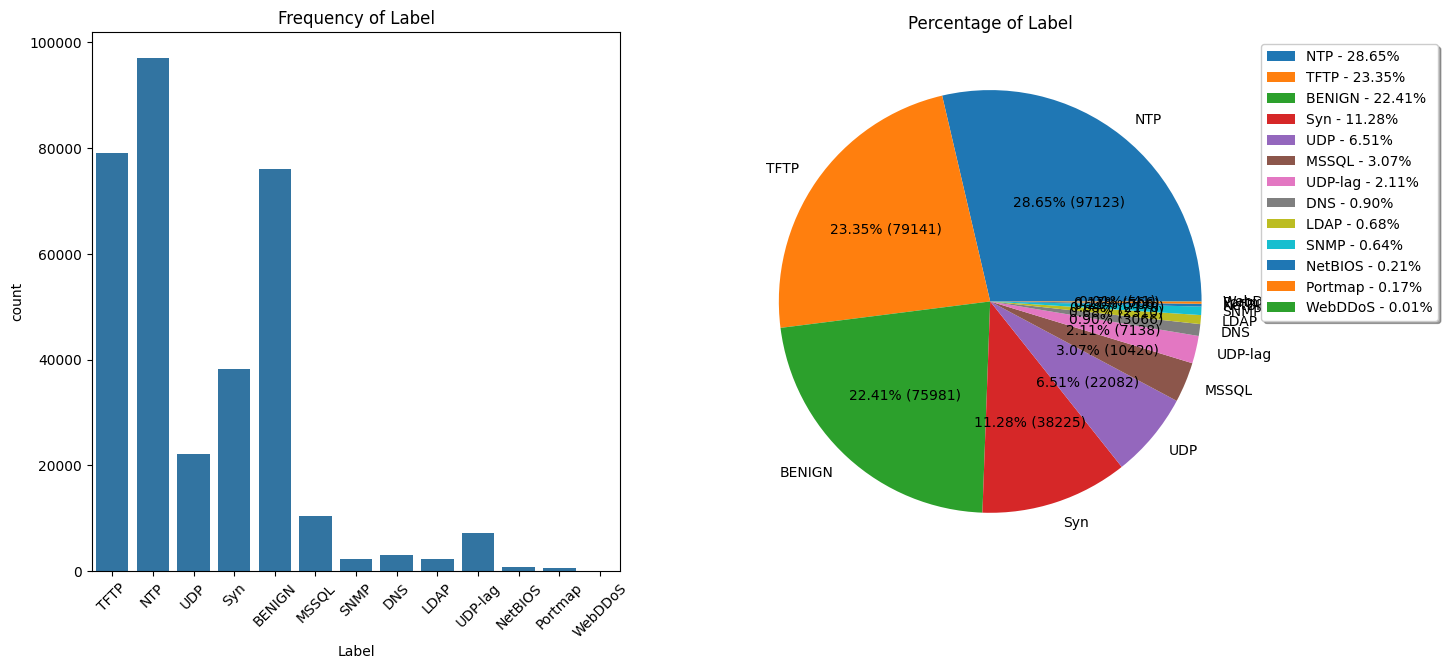

          Protocol      Ratio
Protocol                     
17          247253  72.940937
6            90418  26.673786
0             1306   0.385277




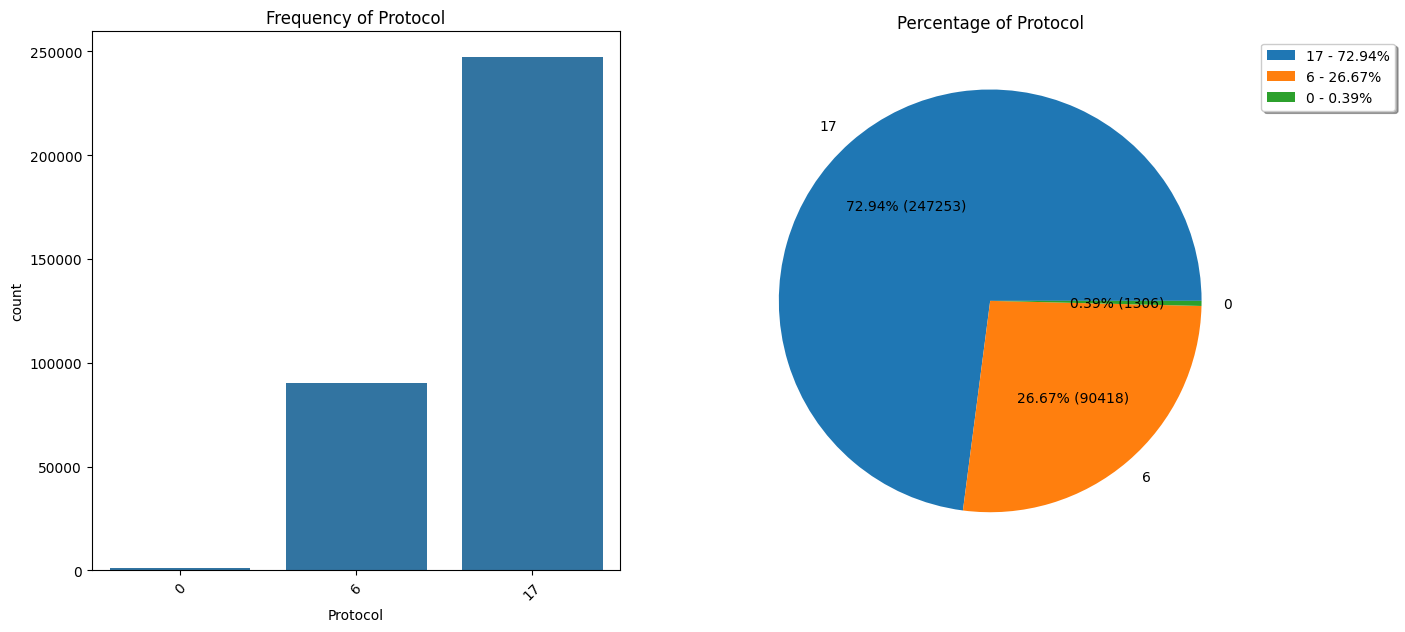

               Fwd PSH Flags      Ratio
Fwd PSH Flags                          
0                     329987  97.347903
1                       8990   2.652097




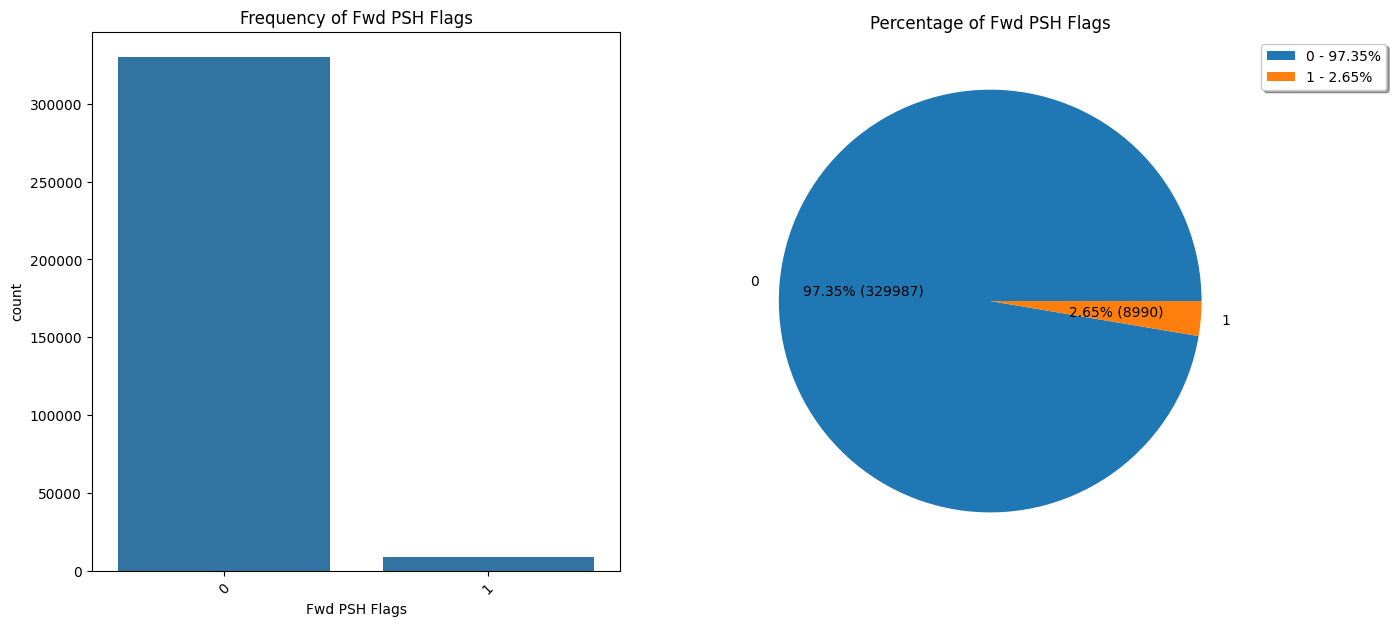

                SYN Flag Count      Ratio
SYN Flag Count                           
0                       338838  99.958994
1                          139   0.041006




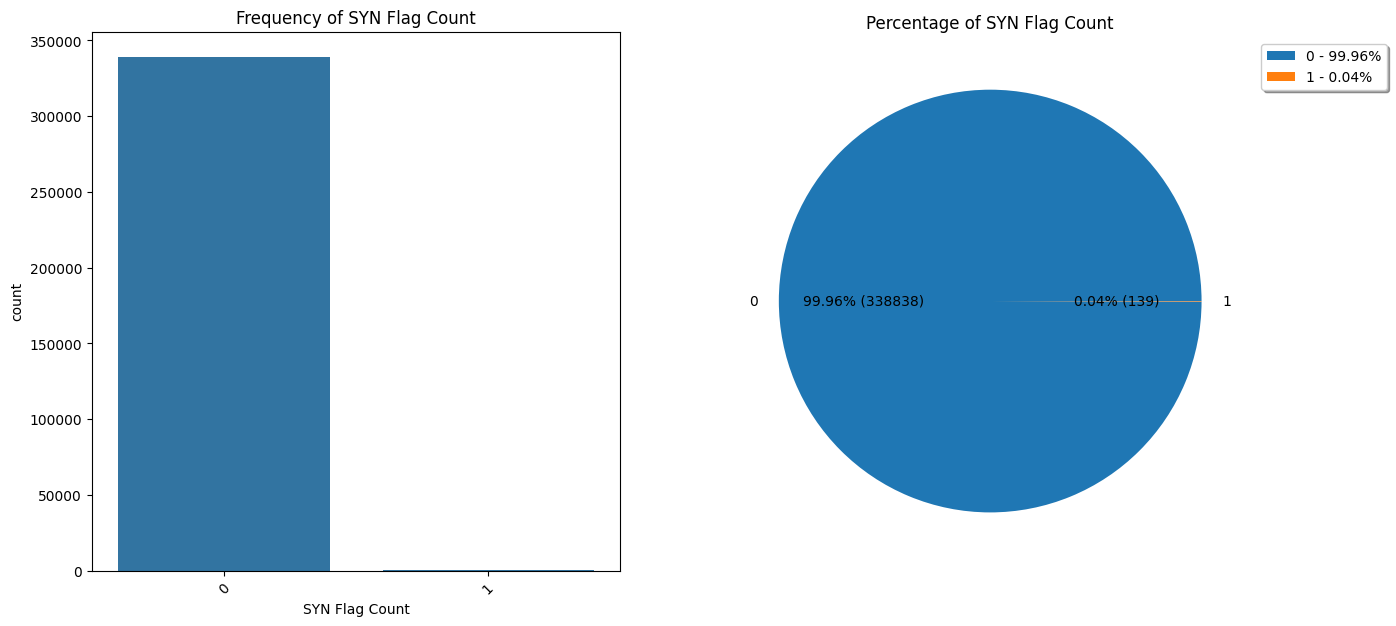

                RST Flag Count      Ratio
RST Flag Count                           
0                       329987  97.347903
1                         8990   2.652097




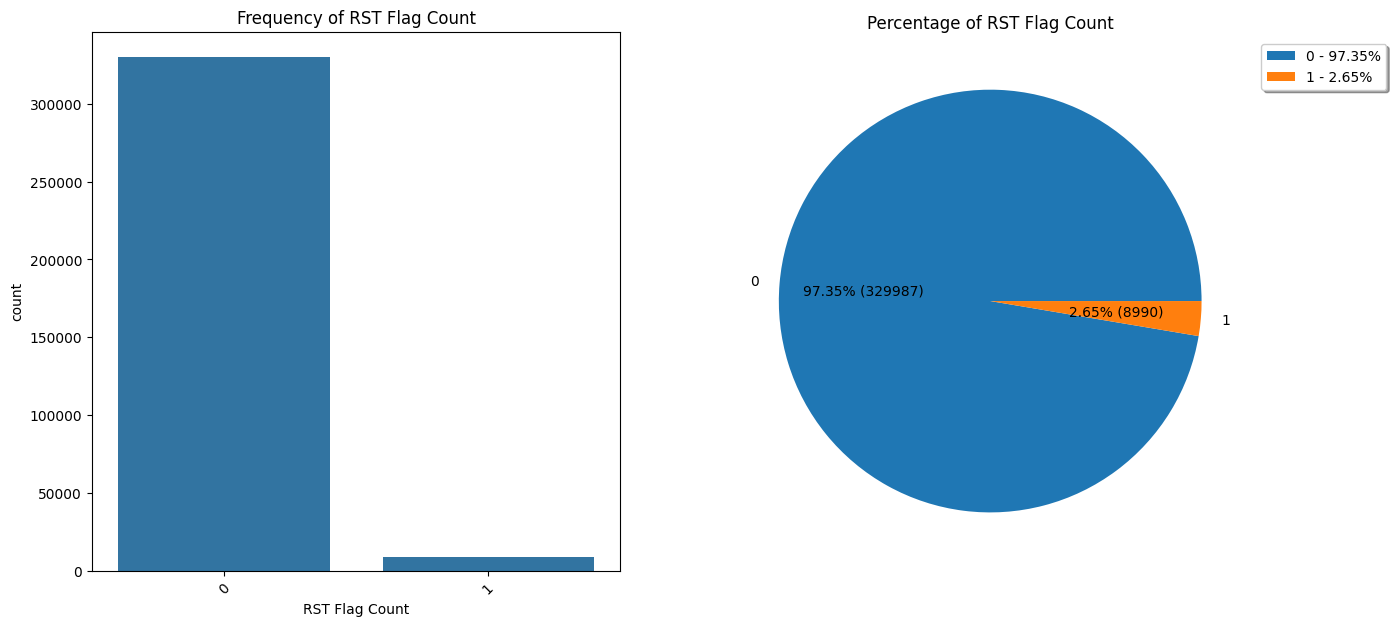

                ACK Flag Count      Ratio
ACK Flag Count                           
0                       279431  82.433616
1                        59546  17.566384




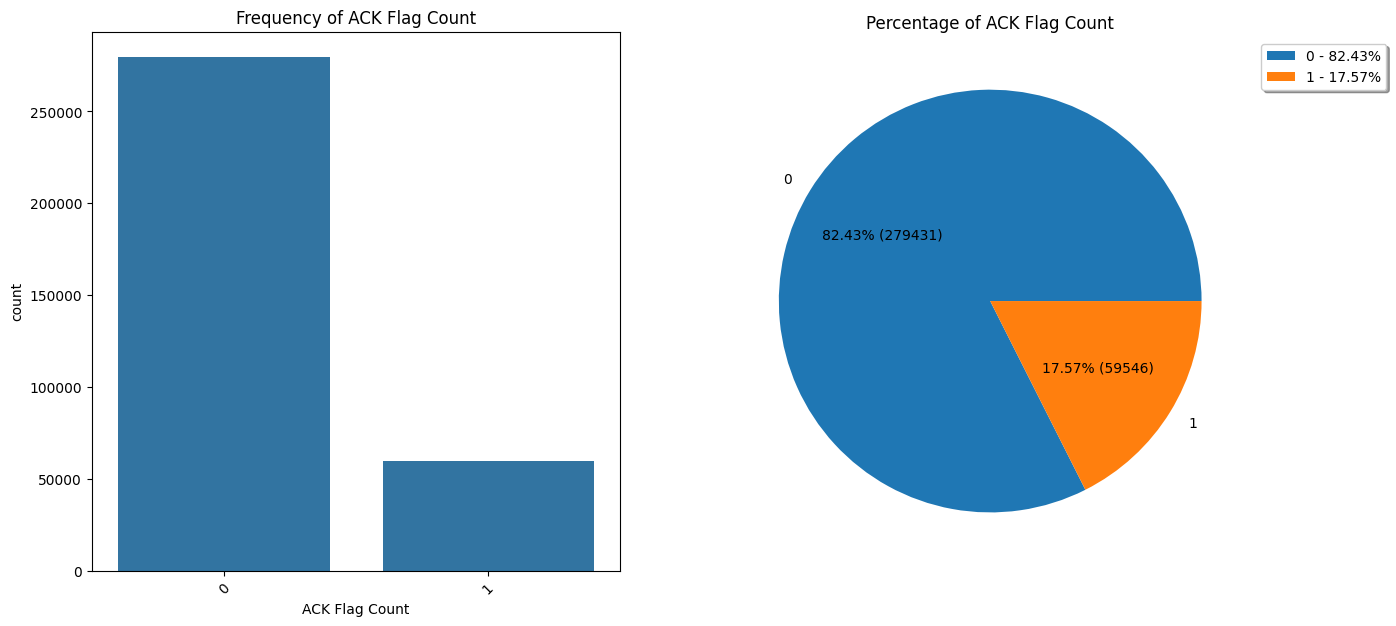

                URG Flag Count      Ratio
URG Flag Count                           
0                       308051  90.876667
1                        30926   9.123333




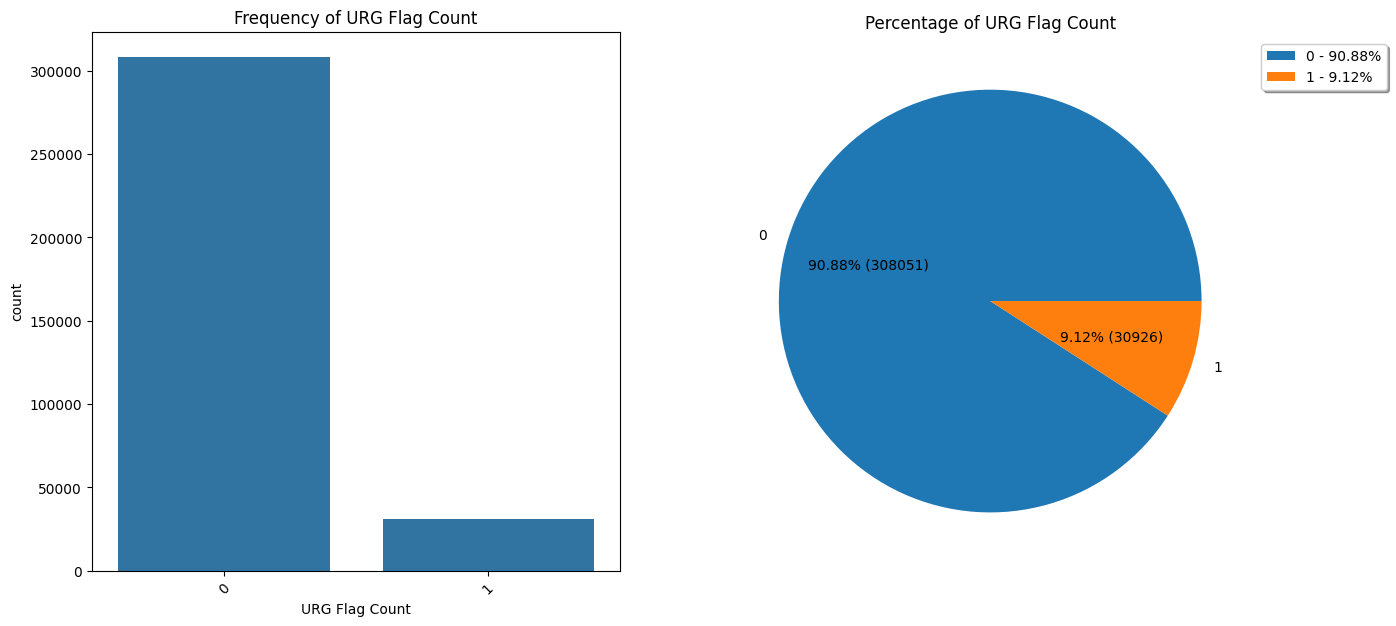

                CWE Flag Count      Ratio
CWE Flag Count                           
0                       323002  95.287291
1                        15975   4.712709




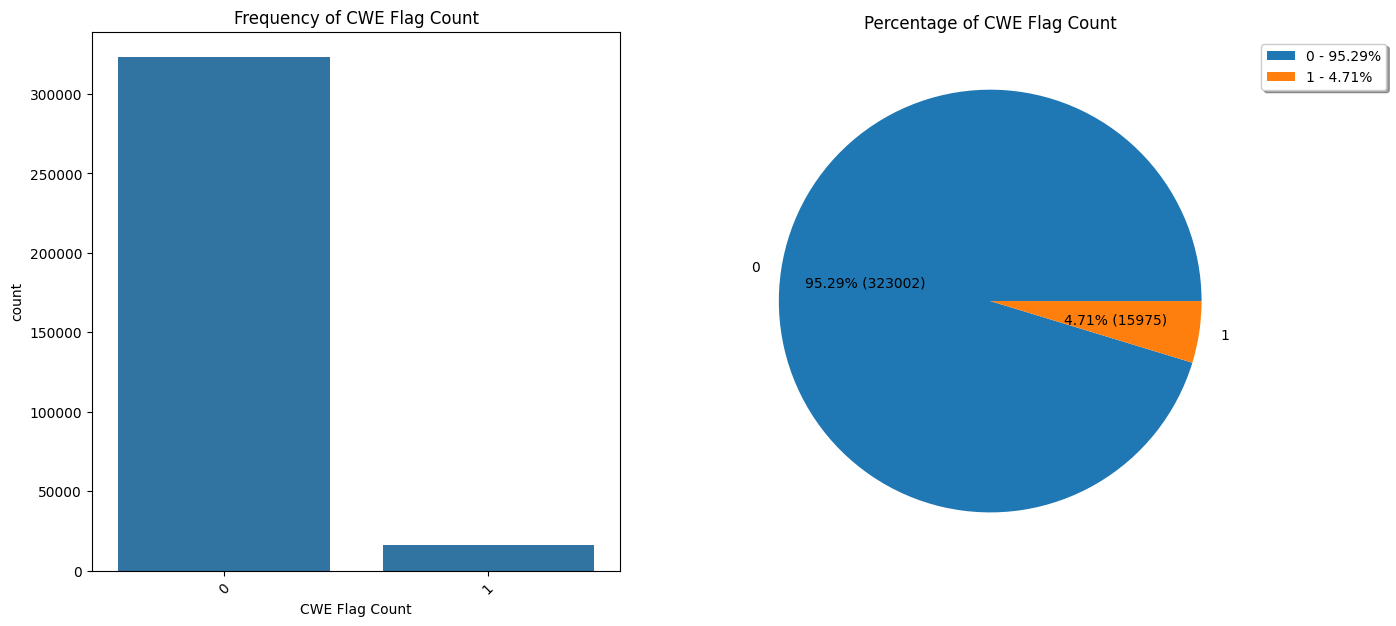

In [260]:
def cat_summary(data, col, plot=False):
    print(pd.DataFrame({col: data[col].value_counts(), "Ratio": data[col].value_counts() / len(data) * 100}))
    print("\n")

    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(15, 7))
        plt.subplot(1, 2, 1)
        sns.countplot(x=col, data = data)
        plt.xticks(rotation=45)
        plt.title(f"Frequency of {col}")

        plt.subplot(1, 2, 2)
        values = data[col].value_counts()
        plt.pie(x=values, labels=values.index, autopct= lambda x: "{:.2f}% ({:.0f})".format(x, x/100 * sum(values)))
        plt.legend(labels = ['{} - {:.2f}%'.format(index, value / sum(values) * 100) for index, value in zip(values.index, values)],
                loc = "upper left",
                bbox_to_anchor = (1, 1),
                fancybox = True,
                shadow = True,
                ncol=1)
        plt.title(f"Percentage of {col}")
        plt.show(block=True)

cat_summary(pd.DataFrame(y_train, columns=['Label']), "Label", True)

for col in cat_columns:
    cat_summary(X_train, col, True)

### Numerical columns

In [261]:
# Distribution Plots for Numerical Columns

def my_histplot(data, col, ax):
    sns.histplot(x=col, data=data, kde=True, ax=ax)
    ax.set_title(f"Histogram of {col}")

def my_distplot(data, col, ax):
    sns.distplot(data[col], ax=ax)
    ax.set_title(f"Distribution of {col}")

def my_kdeplot(data, col, ax):
    sns.kdeplot(x=col, data=data, ax=ax)
    ax.set_title(f"KDE Plot of {col}")

# Relational Plots for Numerical Columns

def my_scatterplot(data, col, ax):
    sns.scatterplot(x=col, data=data, ax=ax)
    ax.set_title(f"Scatter Plot of {col}")

def my_lineplot(data, col, ax):
    sns.lineplot(x=col, data=data, ax=ax)
    ax.set_title(f"Line Plot of {col}")

# Categorical Plots for Categorical Columns

def my_pie_chart(data, col, ax):
    values = data[col].value_counts()
    ax.pie(x=values, labels=values.index, autopct= lambda x: "{:.2f}% ({:.0f})".format(x, x/100 * sum(values)))
    ax.legend(labels = ['{} - {:.2f}%'.format(index, value / sum(values) * 100) for index, value in zip(values.index, values)],
                loc = "upper left",
                bbox_to_anchor = (1, 1),
                fancybox = True,
                shadow = True,
                ncol=1)
    ax.set_title(f"Pie Chart of {col}")

def my_countplot(data, col, ax):
    sns.countplot(x=col, data=data, ax=ax)
    ax.set_title(f"Count Plot of {col}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

def my_boxplot(data, col, ax):
    sns.boxplot(y=col, data=data, ax=ax)

def my_violinplot(data, col, ax):
    sns.violinplot(y=col, data=data, ax=ax)

def my_swarmplot(data, col, ax):
    sns.swarmplot(y=col, data=data, ax=ax)

# Matrix Plots for Numerical Columns
def my_headmap(data, size):
    if size: plt.figure(figsize=size)
    sns.heatmap(data.corr(), annot=True, fmt=".1f", cmap="Blues", annot_kws={"size": 12})
    plt.title("Correlation Matrix")
    plt.show()

def my_vsplot(data, normal_col, label_col):
    plt.figure(figsize=(10, 6), dpi=80)
    plt.bar(list(dict(data[normal_col].value_counts()).key()), dict(data[normal_col].value_counts()).values(), color='r')
    plt.bar(list(dict(data[normal_col][data[label_col] == 1].value_counts()).keys()), dict(data[normal_col][data[label_col] == 1].value_counts()).values().keys(), dict(data[normal_col][data[label_col] == 1].value_counts()).values(), color='b')

    plt.xlabel(normal_col)
    plt.ylabel("Counts")
    plt.title(f"{normal_col} vs {label_col}")
    plt.show()

def plot_charts_grid_single_feature(data, plot_func, size=(12,4), n_col = 1):
    if len(data.columns) == 0:
        return
    n_rows = (len(data.columns) + n_col - 1)
    fig, axes = plt.subplots(n_rows, n_col, figsize=(size[0]*n_col, size[1]*n_rows))
    if len(data.columns) == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(data.columns):
        plot_func(data, col, axes[i])

    for j in range(i+1, n_rows*n_col):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()


In [262]:
# plot_charts_grid_single_feature(X_train[num_columns], my_histplot, size=(12, 4), n_col=2)

In [263]:
# plot_charts_grid_single_feature(X_train[num_columns], my_boxplot, size=(2, 4), n_col=6)

### Packet Size and Flow Duration Analysis

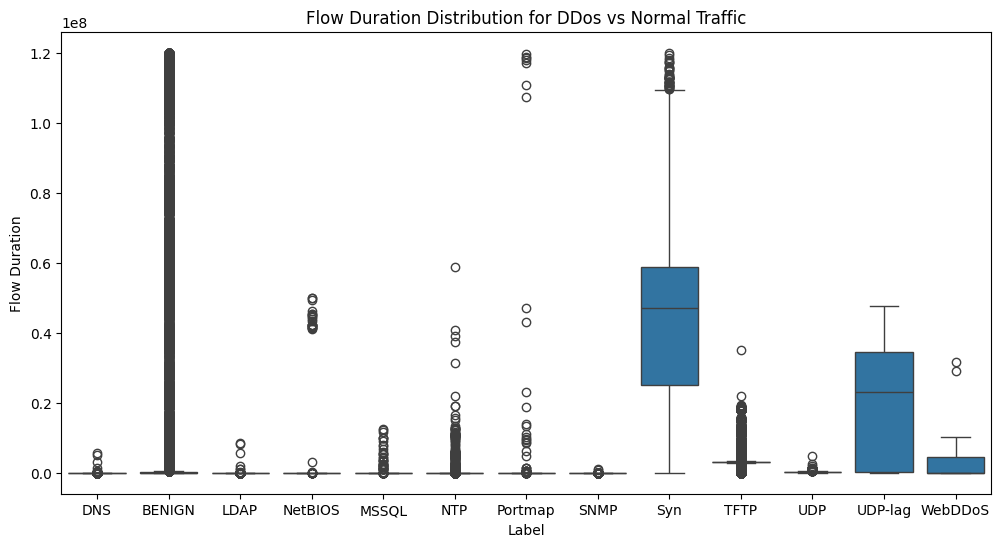

In [264]:
# Boxplot of Flow Duration by Attack Label
plt.figure(figsize=(12, 6))
sns.boxplot(x="Label", y="Flow Duration", data=df)
plt.title("Flow Duration Distribution for DDos vs Normal Traffic")
plt.show()

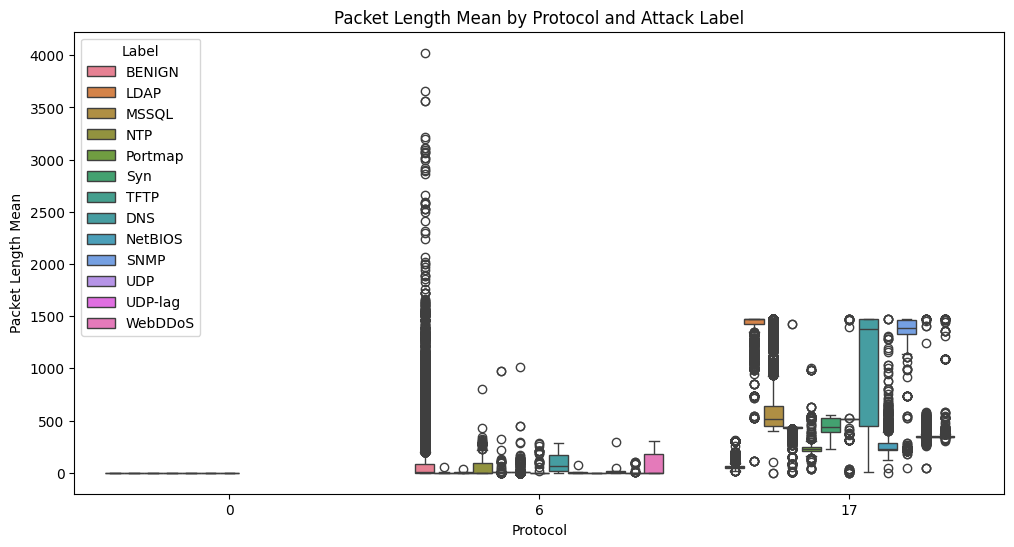

In [265]:
# Boxplot of Packet Length Mean by Protocol and Label
plt.figure(figsize=(12, 6))
sns.boxplot(x="Protocol", y="Packet Length Mean", hue="Label", data=df)
plt.title("Packet Length Mean by Protocol and Attack Label")
plt.show()

### Packet Flags and Attack Patterns

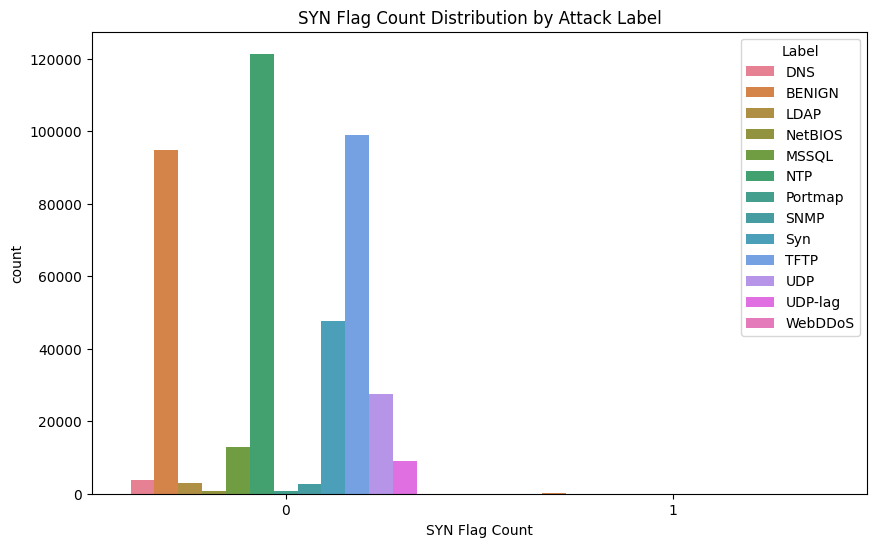

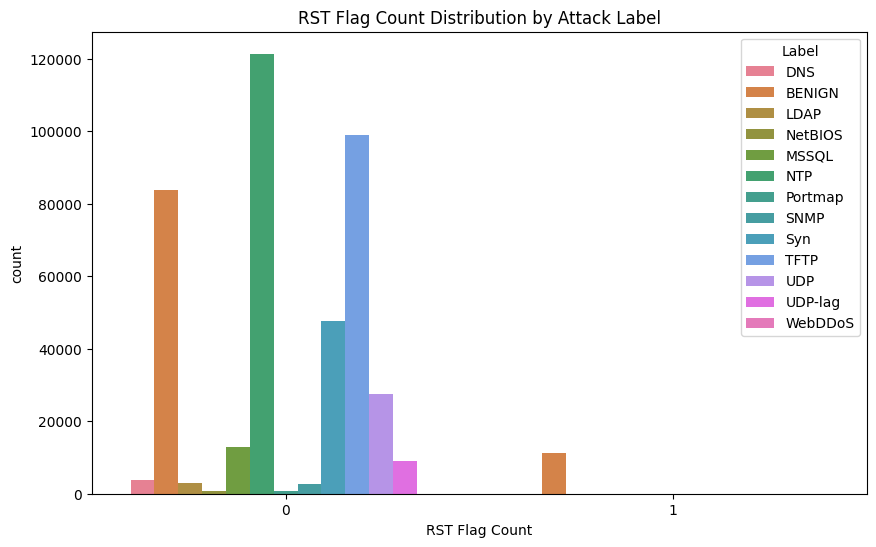

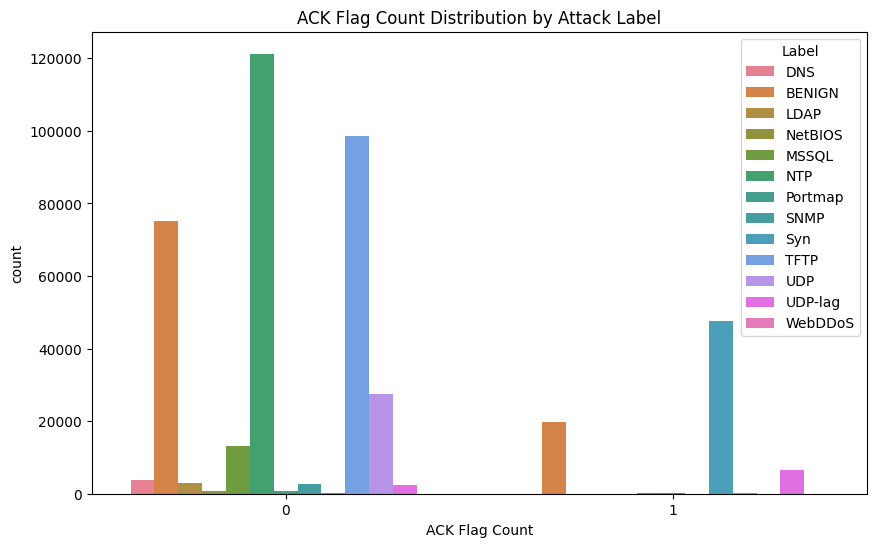

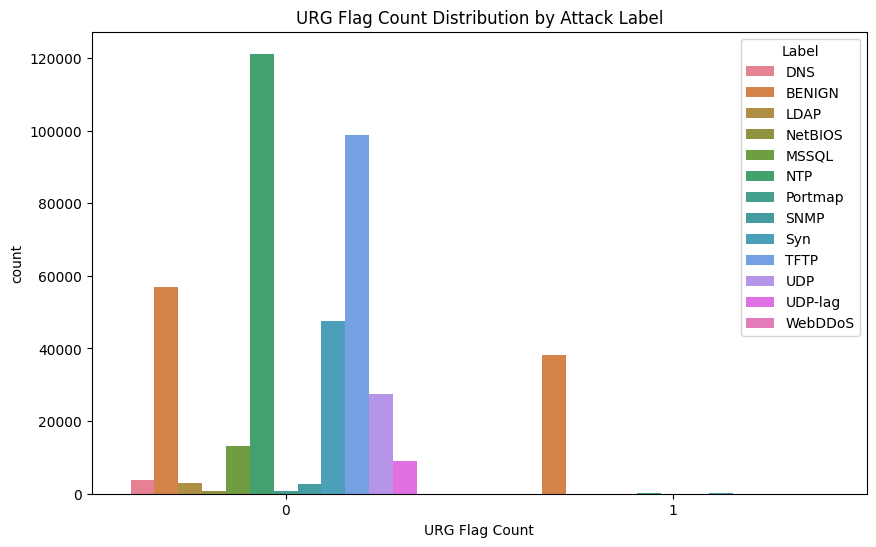

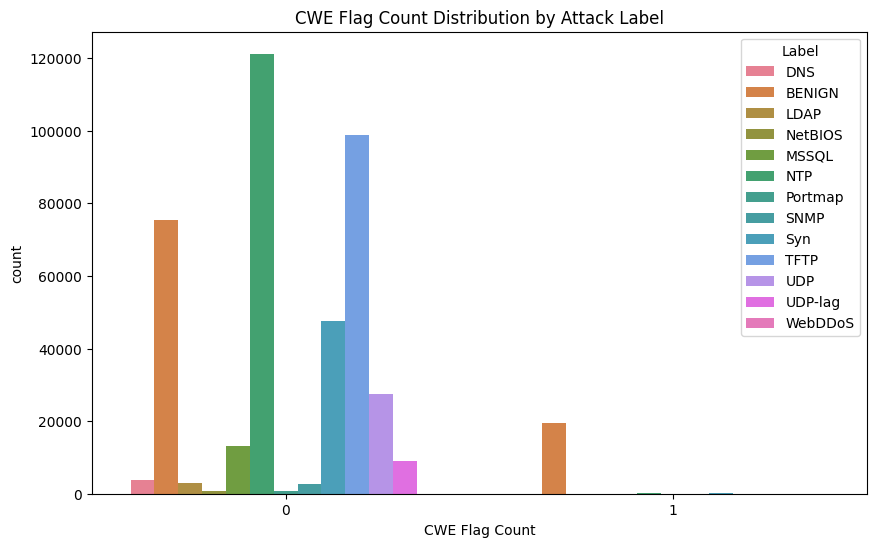

In [266]:
# Counting the number of occurrences of each flag in attack vs normal traffic

flag_cols = [col for col in df.columns if "Flag " in col]

for flag in flag_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=flag, hue="Label", data=df)
    plt.title(f"{flag} Distribution by Attack Label")
    plt.show()

## Class Imbalance, Scaling, Feature Extraction, Encoding

### Weighted Random Sampling

In [267]:
print(f"Original X_train shape: {X_train.shape}")

# Calculate the weights for each class (Inverse Frequency)
# The rarer the class, the higher the weight
class_counts = y_train.value_counts()
class_weights = 1.0 / class_counts

# Map those weights to every single row in your training labels
sample_weights = y_train.map(class_weights)

# Decide how many rows you want in your final balanced dataset.
# Keeping it the same size as your original training set is standard.
n_samples = len(X_train)

# Perform the Weighted Random Sampling
# We sample the INDICES so we can pull the exact same rows from both X and y
sampled_indices = y_train.sample(
    n=n_samples, 
    replace=True, # Must be True so rare attacks can be drawn multiple times
    weights=sample_weights, 
    random_state=42
).index

# Create your new, perfectly balanced training data
X_train_balanced = X_train.loc[sampled_indices]
y_train_balanced = y_train.loc[sampled_indices]

print(f"Balanced X_train shape: {X_train_balanced.shape}")

print("\nClass distribution after Weighted Sampling:")
print(y_train_balanced.value_counts())

Original X_train shape: (338977, 65)
Balanced X_train shape: (338977, 65)

Class distribution after Weighted Sampling:
Label
NetBIOS    26308
SNMP       26286
UDP        26246
DNS        26214
UDP-lag    26153
Syn        26107
MSSQL      26088
Portmap    26026
BENIGN     26004
LDAP       25936
TFTP       25929
WebDDoS    25892
NTP        25788
Name: count, dtype: int64


### Standard Scaling

In [268]:
scaler = StandardScaler()

X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_columns]),
    columns=num_columns,
    index=X_train.index,
)
X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_columns]),
    columns=num_columns,
    index=X_test.index,
)

print(f"Scaled {len(num_columns)} numerical columns (fit on train only)")

Scaled 58 numerical columns (fit on train only)


In [269]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

### PCA

In [270]:
# Retain 95% of the mathematical variance
pca = PCA(n_components=0.95, random_state=42)

# Fit and transform on TRAIN, only transform on TEST
X_train_pca = pd.DataFrame(
    pca.fit_transform(X_train_num),
    index=X_train_num.index
)

X_test_pca = pd.DataFrame(
    pca.transform(X_test_num),
    index=X_test_num.index
)

print(f" PCA reduced numerical features from {X_train_num.shape[1]} to {X_train_pca.shape[1]}")

 PCA reduced numerical features from 58 to 22


In [271]:
joblib.dump(pca, 'pca.pkl')

['pca.pkl']

### One Hot Encoding of categorical columns in X

In [272]:
# 1. Initialize the encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

# 2. Fit only on Training data, then transform both
encoder.fit(X_train[cat_columns].astype(str))

X_train_cat_np = encoder.transform(X_train[cat_columns].astype(str))
X_test_cat_np = encoder.transform(X_test[cat_columns].astype(str))

# 3. Convert back to DataFrame with proper column names
X_train_cat = pd.DataFrame(X_train_cat_np, columns=encoder.get_feature_names_out(cat_columns), index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat_np, columns=encoder.get_feature_names_out(cat_columns), index=X_test.index)

In [273]:
joblib.dump(encoder, 'encoder.pkl')

['encoder.pkl']

In [274]:
X_train = pd.concat([X_train_pca, X_train_cat], axis=1)
X_test = pd.concat([X_test_pca, X_test_cat], axis=1)

# ── Report ────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("POST-TRANSFORM STATE")
print("=" * 60)
print(f"  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"  X_test  : {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"  Dtypes  : {X_train.dtypes.value_counts().to_dict()}")
print(f"  NaN     : {X_train.isnull().sum().sum()}")
print(f"  Columns : {list(X_train.columns)}")


POST-TRANSFORM STATE
  X_train : 338,977 rows × 37 columns
  X_test  : 84,745 rows × 37 columns
  Dtypes  : {dtype('float64'): 22, dtype('int64'): 15}
  NaN     : 0
  Columns : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 'Protocol_0', 'Protocol_17', 'Protocol_6', 'Fwd PSH Flags_0', 'Fwd PSH Flags_1', 'SYN Flag Count_0', 'SYN Flag Count_1', 'RST Flag Count_0', 'RST Flag Count_1', 'ACK Flag Count_0', 'ACK Flag Count_1', 'URG Flag Count_0', 'URG Flag Count_1', 'CWE Flag Count_0', 'CWE Flag Count_1']


### Label Encoding target variable

In [275]:
label_encoder = LabelEncoder()

# Fit on the training labels, and transform both train and test
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Label Mapping Dictionary:")
for attack_name, encoded_number in label_mapping.items():
    print(f"{attack_name}: {encoded_number}")

Label Mapping Dictionary:
BENIGN: 0
DNS: 1
LDAP: 2
MSSQL: 3
NTP: 4
NetBIOS: 5
Portmap: 6
SNMP: 7
Syn: 8
TFTP: 9
UDP: 10
UDP-lag: 11
WebDDoS: 12


In [276]:
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

## Model Training

In [132]:
# Global dictionary to store results from all models
model_evaluations = {}

In [134]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=3e-4, # 0.0003 as requested
    decay_steps=10000,          # How often to apply the decay (adjust based on dataset size)
    decay_rate=0.9              # How much to decay by
)

### 1. Long Short-Term Memory (LSTM) Model

In [141]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[1]
n_classes = 13

lstm_model = Sequential(name="DDoS_LSTM")

# First LSTM Layer (return_sequences=True to pass 3D data to the next LSTM)
lstm_model.add(LSTM(64, return_sequences=True, input_shape=(n_features, 1)))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))

# Second LSTM Layer (returns 2D data for the Dense layers)
lstm_model.add(LSTM(64))
lstm_model.add(BatchNormalization())
lstm_model.add(Dropout(0.3))

# Fully Connected Layers
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(n_classes, activation='softmax'))

lstm_model.compile(
    optimizer=Adam(learning_rate=lr_schedule), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("LSTM Architecture Built!")
lstm_model.summary()

# Training
history_lstm = lstm_model.fit(
    X_train, y_train_encoded,
    epochs=50, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

# --- ADD THIS TO THE END OF KERAS MODEL CELLS ---
print(f"Recording evaluations for {lstm_model.name}...")

# Keras .predict() natively returns probabilities for softmax outputs
y_proba = lstm_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)
# We use the final validation accuracy as a proxy for CV score to save compute time
pseudo_cv_score = history_lstm.history['val_accuracy'][-1] 

model_evaluations[lstm_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}

LSTM Architecture Built!


Model: "DDoS_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 37, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 37, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,429 (236.05 KB)

 Trainable params: 60,173 (235.05 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 82s 74ms/step - accuracy: 0.7907 - loss: 0.6771 - val_accuracy: 0.9080 - val_loss: 0.2724
Epoch 2/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 84s 79ms/step - accuracy: 0.9103 - loss: 0.2911 - val_accuracy: 0.9244 - val_loss: 0.2295
Epoch 3/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 136s 73ms/step - accuracy: 0.9273 - loss: 0.2358 - val_accuracy: 0.9357 - val_loss: 0.2035
Epoch 4/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 76s 72ms/step - accuracy: 0.9344 - loss: 0.2106 - val_accuracy: 0.9455 - val_loss: 0.1708
Epoch 5/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 76s 72ms/step - accuracy: 0.9398 - loss: 0.1921 - val_accuracy: 0.9395 - val_loss: 0.1892
Epoch 6/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.9431 - loss: 0.1803 - val_accuracy: 0.9483 - val_loss: 0.1613
Epoch 7/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 77s 73ms/step - accuracy: 0.9460 - loss: 0.1698 - val_accuracy: 0.9502 - val_loss: 0.1466
Epoch 8/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 77s 72ms/step - accuracy: 0.9479 

### 2. Multi-Layer Perceptron (MLP) Classifier

In [277]:
from tensorflow.keras.layers import Flatten

mlp_model = Sequential(name="DDoS_MLP")

# Flatten the (n_features, 1) input to a flat vector of (n_features)
mlp_model.add(Flatten(input_shape=(n_features, 1)))

# Deep Dense Network
mlp_model.add(Dense(512, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.4))

mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(BatchNormalization())
mlp_model.add(Dropout(0.4))

mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dropout(0.3))

mlp_model.add(Dense(n_classes, activation='softmax'))

mlp_model.compile(
    optimizer=Adam(learning_rate=lr_schedule), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("MLP Architecture Built!")
mlp_model.summary()

# Training
history_mlp = mlp_model.fit(
    X_train, y_train_encoded,
    epochs=50, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

# --- ADD THIS TO THE END OF KERAS MODEL CELLS ---
print(f"Recording evaluations for {mlp_model.name}...")

# Keras .predict() natively returns probabilities for softmax outputs
y_proba = mlp_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)

# We use the final validation accuracy as a proxy for CV score to save compute time
pseudo_cv_score = history_mlp.history['val_accuracy'][-1] 

model_evaluations[mlp_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}

MLP Architecture Built!


Model: "DDoS_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 37)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,429 (736.05 KB)

 Trainable params: 186,893 (730.05 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9211 - loss: 0.2818 - val_accuracy: 0.9443 - val_loss: 0.1633
Epoch 2/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9442 - loss: 0.1775 - val_accuracy: 0.9490 - val_loss: 0.1437
Epoch 3/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9491 - loss: 0.1558 - val_accuracy: 0.9553 - val_loss: 0.1320
Epoch 4/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9524 - loss: 0.1436 - val_accuracy: 0.9573 - val_loss: 0.1220
Epoch 5/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9551 - loss: 0.1354 - val_accuracy: 0.9607 - val_loss: 0.1148
Epoch 6/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9569 - loss: 0.1299 - val_accuracy: 0.9619 - val_loss: 0.1117
Epoch 7/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9587 - loss: 0.1246 - val_accuracy: 0.9647 - val_loss: 0.1068
Epoch 8/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9603 - l

### 4. 1D Transformer Model

In [142]:
from tensorflow.keras import layers, Model

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # Attention and Normalization
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Build the model
inputs = layers.Input(shape=(n_features, 1))

# Apply the Transformer Block
x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1)

# Global average pooling creates a 1D vector from the 3D attention output
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

transformer_model = Model(inputs, outputs, name="DDoS_1D_Transformer")

transformer_model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Transformer Architecture Built!")
transformer_model.summary()

# Training
history_transformer = transformer_model.fit(
    X_train, y_train_encoded,
    epochs=50, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

# --- ADD THIS TO THE END OF KERAS MODEL CELLS ---
print(f"Recording evaluations for {transformer_model.name}...")

# Keras .predict() natively returns probabilities for softmax outputs
y_proba = transformer_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)

# We use the final validation accuracy as a proxy for CV score to save compute time
pseudo_cv_score = history_transformer.history['val_accuracy'][-1] 

model_evaluations[transformer_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}


Transformer Architecture Built!


Model: "DDoS_1D_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 37, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 37, 1)     │      1,793 │ input_layer_7[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 37, 1)     │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 37, 1)     │          2 │ dropout_22[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 37, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 37, 128)   │        256 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 37, 128)   │          0 │ conv1d[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 37, 1)     │        129 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 37, 1)     │          2 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 37, 1)     │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ add_1[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │        256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 128)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 13)        │      1,677 │ dropout_24[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,115 (16.07 KB)

 Trainable params: 4,115 (16.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 47s 42ms/step - accuracy: 0.3220 - loss: 1.8734 - val_accuracy: 0.4495 - val_loss: 1.6884
Epoch 2/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.4281 - loss: 1.6264 - val_accuracy: 0.4822 - val_loss: 1.5535
Epoch 3/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.4609 - loss: 1.5108 - val_accuracy: 0.4783 - val_loss: 1.4495
Epoch 4/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - accuracy: 0.4551 - loss: 1.4279 - val_accuracy: 0.4884 - val_loss: 1.3792
Epoch 5/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.4550 - loss: 1.3735 - val_accuracy: 0.4313 - val_loss: 1.3296
Epoch 6/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.4937 - loss: 1.3326 - val_accuracy: 0.5453 - val_loss: 1.2925
Epoch 7/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 46s 43ms/step - accuracy: 0.5522 - loss: 1.3017 - val_accuracy: 0.5454 - val_loss: 1.2627
Epoch 8/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 79s 40ms/step - accuracy: 0.5776 -

### 5. 1D CNN + Inception Module

In [143]:
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Concatenate, GlobalAveragePooling1D

def inception_1d_module(x, filters):
    # Branch 1: 1x1 Convolution (Looks at individual features)
    branch1 = Conv1D(filters=filters, kernel_size=1, activation='relu', padding='same')(x)
    
    # Branch 2: 1x1 Conv followed by 3x3 Conv (Looks at small groupings of features)
    branch2 = Conv1D(filters=filters, kernel_size=1, activation='relu', padding='same')(x)
    branch2 = Conv1D(filters=filters, kernel_size=3, activation='relu', padding='same')(branch2)
    
    # Branch 3: 1x1 Conv followed by 5x5 Conv (Looks at wider groupings of features)
    branch3 = Conv1D(filters=filters, kernel_size=1, activation='relu', padding='same')(x)
    branch3 = Conv1D(filters=filters, kernel_size=5, activation='relu', padding='same')(branch3)
    
    # Branch 4: MaxPooling followed by 1x1 Conv
    branch4 = MaxPooling1D(pool_size=3, strides=1, padding='same')(x)
    branch4 = Conv1D(filters=filters, kernel_size=1, activation='relu', padding='same')(branch4)
    
    # Concatenate all branches together
    output = Concatenate(axis=-1)([branch1, branch2, branch3, branch4])
    return output

# Build the model using Functional API
inputs = Input(shape=(n_features, 1))

# Initial Conv Layer
x = Conv1D(filters=64, kernel_size=7, strides=2, activation='relu', padding='same')(inputs)
x = MaxPooling1D(pool_size=3, strides=2, padding='same')(x)

# Apply two Inception modules
x = inception_1d_module(x, filters=32)
x = inception_1d_module(x, filters=64)

# Flatten using Global Average Pooling (better than Flatten() for Inception networks)
x = GlobalAveragePooling1D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)

outputs = Dense(n_classes, activation='softmax')(x)

inception_model = Model(inputs, outputs, name="DDoS_Inception_1D")

inception_model.compile(
    optimizer=Adam(learning_rate=lr_schedule), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

print("Inception Architecture Built!")
inception_model.summary()

# Training
history_inception = inception_model.fit(
    X_train, y_train_encoded,
    epochs=50, batch_size=256, validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

# --- ADD THIS TO THE END OF KERAS MODEL CELLS ---
print(f"Recording evaluations for {inception_model.name}...")

# Keras .predict() natively returns probabilities for softmax outputs
y_proba = inception_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)

# We use the final validation accuracy as a proxy for CV score to save compute time
pseudo_cv_score = history_inception.history['val_accuracy'][-1] 

model_evaluations[inception_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}

Inception Architecture Built!


Model: "DDoS_Inception_1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 37, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 19, 64)    │        512 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 10, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 10, 32)    │      2,080 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 10, 32)    │      2,080 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 10, 64)    │          0 │ max_pooling1d[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 32)    │      2,080 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 10, 32)    │      3,104 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 10, 32)    │      5,152 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 10, 32)    │      2,080 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10, 128)   │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_7[0][0],   │
│                     │                   │            │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 10, 64)    │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 10, 64)    │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 10, 128)   │          0 │ concatenate[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 10, 64)    │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 10, 64)    │     12,352 │ conv1d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 10, 64)    │     20,544 │ conv1d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 10, 64)    │      8,256 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 10, 256)   │          0 │ conv1d_9[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_11[0][0],  │
│                     │                   │            │ conv1d_13[0][0],  │
│                     │                   │            │ conv1d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ concatenate_1[0]

 Total params: 183,373 (716.30 KB)

 Trainable params: 183,373 (716.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.8937 - loss: 0.3723 - val_accuracy: 0.9456 - val_loss: 0.1763
Epoch 2/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9464 - loss: 0.1704 - val_accuracy: 0.9519 - val_loss: 0.1543
Epoch 3/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9499 - loss: 0.1553 - val_accuracy: 0.9522 - val_loss: 0.1483
Epoch 4/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9521 - loss: 0.1462 - val_accuracy: 0.9524 - val_loss: 0.1373
Epoch 5/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9529 - loss: 0.1418 - val_accuracy: 0.9524 - val_loss: 0.1387
Epoch 6/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9536 - loss: 0.1383 - val_accuracy: 0.9529 - val_loss: 0.1389
Epoch 7/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.9550 - loss: 0.1332 - val_accuracy: 0.9583 - val_loss: 0.1245
Epoch 8/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9558 -

### 6. CNN Model

In [144]:
# --- 1. Define Dimensions ---
# Dynamically grab the number of features from your reshaped 3D data
n_features = X_train.shape[1] 
n_classes = 13 # 1 BENIGN + 12 Attack types

# --- 2. Build the Model Architecture ---
cnn_model = Sequential(name="DDoS_1D_CNN")

# First Convolutional Block (Extracting low-level patterns from the PCA components)
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_features, 1)))
cnn_model.add(MaxPooling1D(pool_size=2))

# Second Convolutional Block (Extracting deeper patterns)
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=2))

# Flattening to 1D
cnn_model.add(Flatten())

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(3648, activation='relu'))
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dense(64, activation='relu'))



# Output Layer (Softmax for multi-class probability)
cnn_model.add(Dense(n_classes, activation='softmax'))

custom_adam = Adam(learning_rate=lr_schedule, beta_1=0.9)
# --- 3. Compile the Model ---
cnn_model.compile(
    optimizer=custom_adam, 
    loss='sparse_categorical_crossentropy', # Used because y is Label Encoded (0-12)
    metrics=['accuracy']
)

print("Model architecture built successfully!\n")
cnn_model.summary()

# --- 4. Define Early Stopping (Crucial for large datasets) ---
# This monitors the validation loss. If the model stops improving for 5 epochs, 
# it automatically stops training to save time and prevent overfitting.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# --- 5. Train the Model ---
print("\nStarting model training...")
# batch_size=256 is highly recommended for the massive CIC dataset
history = cnn_model.fit(
    X_train, 
    y_train_encoded,
    epochs=50, 
    batch_size=256, 
    validation_split=0.2, # Uses 20% of training data to validate during training
    callbacks=[early_stop],
    verbose=1
)

# --- 6. Evaluate the Model on the Unseen Test Data ---
print("\nEvaluating model on test data...")
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%\n")

# --- 7. Generate a Detailed Classification Report ---
# This will show you exactly which attacks the model is good at catching and which it struggles with
print("Generating Detailed Classification Report...")
# Keras .predict() natively returns probabilities for softmax outputs
y_proba = cnn_model.predict(X_test, batch_size=256)
y_pred = np.argmax(y_proba, axis=1)

# Pass the label names we extracted earlier to make the report readable
target_names = label_encoder.classes_ 
report = classification_report(y_test_encoded, y_pred, target_names=target_names)
print(report)

# --- ADD THIS TO THE END OF KERAS MODEL CELLS ---
print(f"Recording evaluations for {cnn_model.name}...")



# We use the final validation accuracy as a proxy for CV score to save compute time
pseudo_cv_score = history.history['val_accuracy'][-1] 

model_evaluations[cnn_model.name] = {
    "y_pred": y_pred,
    "y_proba": y_proba,
    "cv_score": pseudo_cv_score
}

Model architecture built successfully!



Model: "DDoS_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 35, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 17, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 15, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3648)           │     1,637,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │       467,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,126,733 (8.11 MB)

 Trainable params: 2,126,733 (8.11 MB)

 Non-trainable params: 0 (0.00 B)


Starting model training...
Epoch 1/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - accuracy: 0.9257 - loss: 0.2605 - val_accuracy: 0.9493 - val_loss: 0.1585
Epoch 2/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.9478 - loss: 0.1614 - val_accuracy: 0.9531 - val_loss: 0.1390
Epoch 3/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - accuracy: 0.9505 - loss: 0.1482 - val_accuracy: 0.9534 - val_loss: 0.1382
Epoch 4/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9523 - loss: 0.1408 - val_accuracy: 0.9569 - val_loss: 0.1270
Epoch 5/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accuracy: 0.9535 - loss: 0.1356 - val_accuracy: 0.9581 - val_loss: 0.1233
Epoch 6/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.9545 - loss: 0.1311 - val_accuracy: 0.9600 - val_loss: 0.1254
Epoch 7/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.9554 - loss: 0.1277 - val_accuracy: 0.9604 - val_loss: 0.1183
Epoch 8/50
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 24s 23

Evaluating Models:   0%|          | 0/5 [00:00<?, ?it/s]

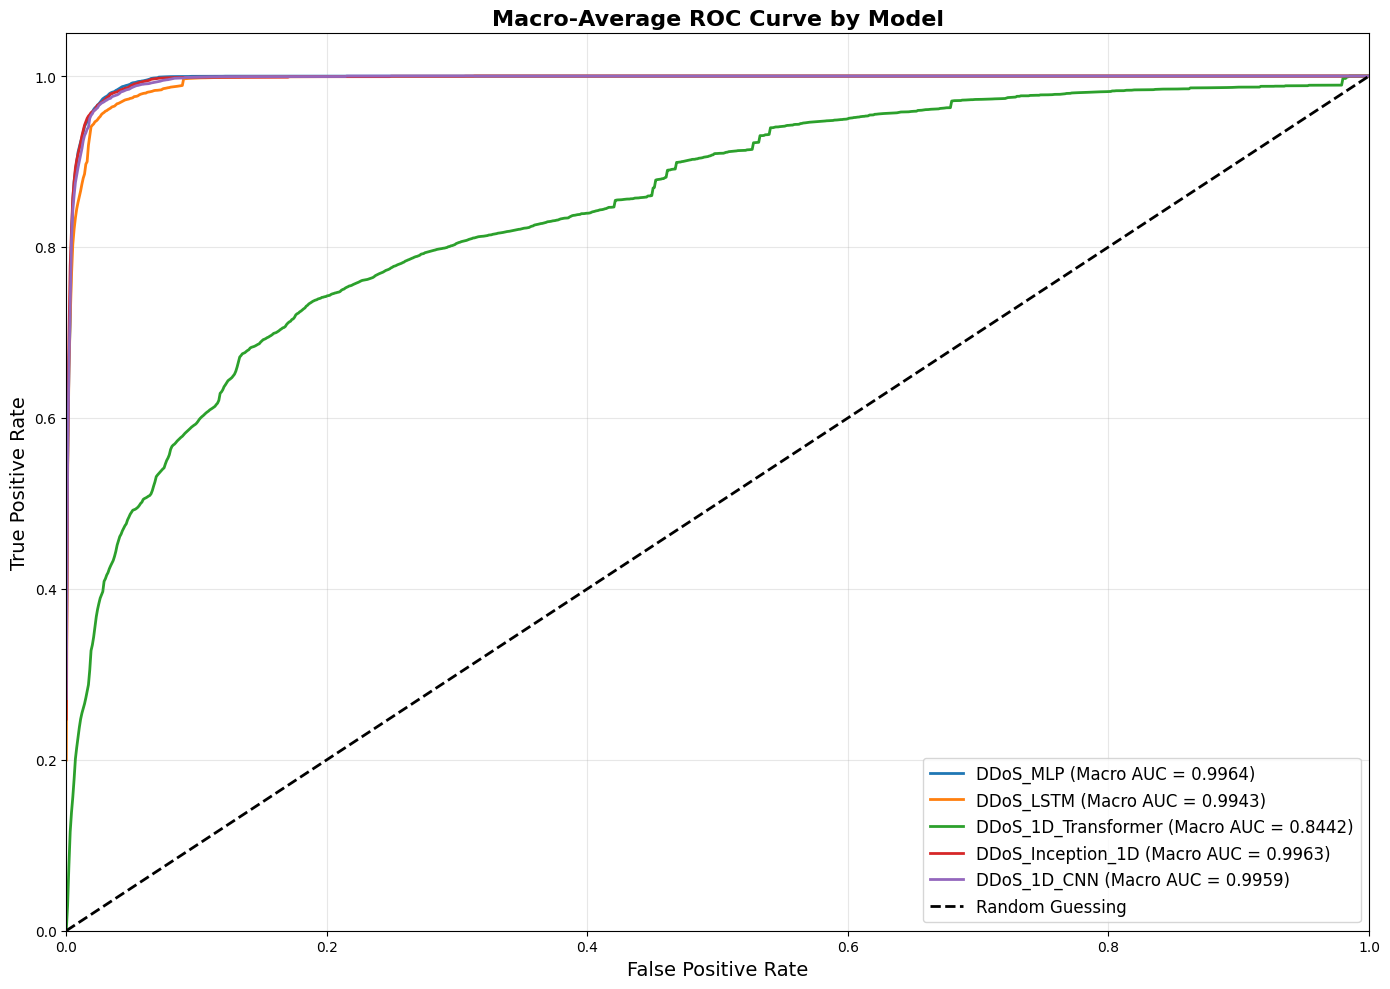


🏆 FINAL MODEL EVALUATION METRICS 🏆


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC (Weighted),Proxy CV Score (Val Acc)
0,DDoS_MLP,0.969792,0.970566,0.969792,0.967981,0.999289,0.971178
1,DDoS_LSTM,0.968647,0.967805,0.968647,0.966944,0.999042,0.967609
2,DDoS_1D_Transformer,0.707971,0.663377,0.707971,0.681389,0.915003,0.708301
3,DDoS_Inception_1D,0.971267,0.970639,0.971267,0.969676,0.999285,0.970190
4,DDoS_1D_CNN,0.968683,0.967599,0.968683,0.966921,0.999190,0.965204


In [145]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from IPython.display import display

def evaluate_all_models(eval_dict, y_true):
    scores_list = []
    
    # Initialize plot for ROC curves
    plt.figure(figsize=(14, 10))
    
    for name, data in tqdm(eval_dict.items(), desc="Evaluating Models"):
        y_pred = data["y_pred"]
        y_proba = data["y_proba"]
        cv_score = data["cv_score"]
        
        # Calculate Metrics
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        
        # OVR (One-vs-Rest) ROC AUC for multiclass
        roc_auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="weighted")
        
        # Append scores
        scores_list.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC (Weighted)": roc_auc,
            "Proxy CV Score (Val Acc)": cv_score
        })
        
        # ROC Curve Plotting 
        # PRO TIP: Plotting all 13 classes for 5 models = 65 lines. 
        # To keep it readable, we plot the Macro-Average ROC for each model instead.
        from sklearn.metrics import auc
        fpr_grid = np.linspace(0.0, 1.0, 1000)
        mean_tpr = np.zeros_like(fpr_grid)
        
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true, y_proba[:, i], pos_label=i)
            mean_tpr += np.interp(fpr_grid, fpr, tpr)
            
        mean_tpr /= n_classes
        macro_auc = auc(fpr_grid, mean_tpr)
        
        plt.plot(fpr_grid, mean_tpr, linewidth=2, label=f'{name} (Macro AUC = {macro_auc:.4f})')

    # Finalize Plot
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Random Guessing")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('Macro-Average ROC Curve by Model', fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Create and Display DataFrame
    scores_df = pd.DataFrame(scores_list)
    # Reorder columns slightly for better flow
    
    print("\n" + "="*50)
    print("🏆 FINAL MODEL EVALUATION METRICS 🏆")
    print("="*50)
    display(scores_df.style.background_gradient(cmap='viridis', subset=['Accuracy', 'F1 Score', 'ROC AUC (Weighted)']))
    
    return scores_df

# Execute the evaluation using your encoded test labels
final_scores = evaluate_all_models(model_evaluations, y_test_encoded)